ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons
Axis norm: 0.3795185614332935
Training AUC: 1.0


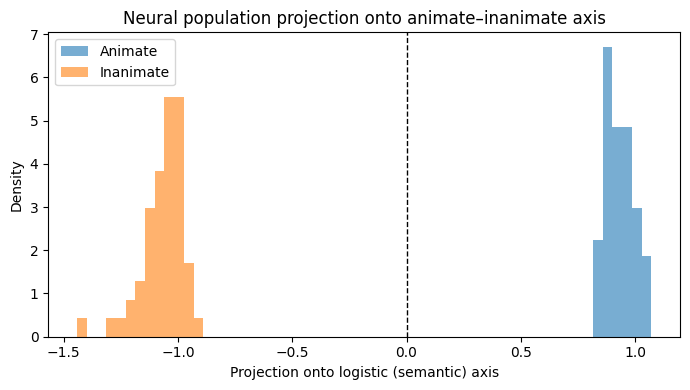

In [1]:
"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
labels = (top1 <= 397).astype(int)

# ============================================================
# LOGISTIC REGRESSION ON NEURAL RESPONSES
# ============================================================

# Standardize neurons (important for a meaningful axis)
scaler = StandardScaler(with_mean=True, with_std=True)
Rz = scaler.fit_transform(R)

# Logistic regression (L2 is fine; saga handles large p well)
clf = LogisticRegression(
    penalty="l2",
    solver="saga",
    max_iter=5000,
    n_jobs=-1
)

clf.fit(Rz, labels)

# Logistic axis (semantic direction)
w = clf.coef_.ravel()        # (neurons,)
b = clf.intercept_[0]

print("Axis norm:", np.linalg.norm(w))
print("Training AUC:", roc_auc_score(labels, clf.decision_function(Rz)))

# ============================================================
# PROJECTION ONTO LOGISTIC AXIS
# ============================================================

# Signed margin / decision coordinate
proj = Rz @ w + b    # (images,)

# Optional: normalize for plotting
proj = proj / np.std(proj)

# ============================================================
# HISTOGRAM PLOT
# ============================================================

plt.figure(figsize=(7, 4))

bins = np.linspace(proj.min(), proj.max(), 60)

plt.hist(
    proj[labels == 1],
    bins=bins,
    density=True,
    alpha=0.6,
    label="Animate",
    color="tab:blue"
)

plt.hist(
    proj[labels == 0],
    bins=bins,
    density=True,
    alpha=0.6,
    label="Inanimate",
    color="tab:orange"
)

plt.axvline(0, color="k", linestyle="--", linewidth=1)

plt.xlabel("Projection onto logistic (semantic) axis")
plt.ylabel("Density")
plt.title("Neural population projection onto animate–inanimate axis")
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

loo = LeaveOneOut()

y_true = []
y_pred = []
y_score = []

for train_idx, test_idx in loo.split(R):
    # Split
    R_train, R_test = R[train_idx], R[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    # Standardize using TRAIN ONLY
    scaler = StandardScaler(with_mean=True, with_std=True)
    R_train_z = scaler.fit_transform(R_train)
    R_test_z  = scaler.transform(R_test)

    # Fit logistic regression
    clf = LogisticRegression(
        penalty="l2",
        solver="saga",
        max_iter=5000
    )
    clf.fit(R_train_z, y_train)

    # Predict
    score = clf.decision_function(R_test_z)[0]
    pred  = int(score > 0)

    y_true.append(y_test[0])
    y_pred.append(pred)
    y_score.append(score)

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_score = np.array(y_score)

acc = (y_true == y_pred).mean()

print(f"LOOCV accuracy: {acc:.3f}")
print("Animate accuracy:", (y_pred[y_true==1] == 1).mean())
print("Inanimate accuracy:", (y_pred[y_true==0] == 0).mean())
from sklearn.metrics import roc_auc_score
print("LOOCV AUC:", roc_auc_score(y_true, y_score))


LOOCV accuracy: 0.686
Animate accuracy: 0.6507936507936508
Inanimate accuracy: 0.7272727272727273
LOOCV AUC: 0.7884559884559885


In [3]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

def angle(u, v, eps=1e-12):
    u = u / (np.linalg.norm(u) + eps)
    v = v / (np.linalg.norm(v) + eps)
    return np.degrees(np.arccos(np.clip(u @ v, -1, 1)))

Cs = np.logspace(-4, 2, 10)
loo = LeaveOneOut()

results = []

for C in Cs:
    y_true, y_pred, margins = [], [], []
    ws = []

    for tr, te in loo.split(R):
        Rtr, Rte = R[tr], R[te]
        ytr, yte = labels[tr], labels[te]

        sc = StandardScaler()
        Xtr = sc.fit_transform(Rtr)
        Xte = sc.transform(Rte)

        clf = LogisticRegression(penalty="l2", solver="saga", max_iter=5000, C=C)
        clf.fit(Xtr, ytr)

        w = clf.coef_.ravel()
        ws.append(w)

        score = clf.decision_function(Xte)[0]
        pred = int(score > 0)

        y_true.append(yte[0])
        y_pred.append(pred)
        margins.append(abs(score))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    margins = np.array(margins)

    # axis instability = average angle to mean axis
    wbar = np.mean(np.stack(ws), axis=0)
    angs = [angle(w, wbar) for w in ws]

    results.append({
        "C": C,
        "acc": (y_true == y_pred).mean(),
        "median_abs_margin": np.median(margins),
        "mean_axis_angle_deg": float(np.mean(angs)),
    })

for r in results:
    print(r)


{'C': np.float64(0.0001), 'acc': np.float64(0.6949152542372882), 'median_abs_margin': np.float64(0.4904150939276901), 'mean_axis_angle_deg': 4.728826589061761}
{'C': np.float64(0.00046415888336127773), 'acc': np.float64(0.6864406779661016), 'median_abs_margin': np.float64(0.8418744748709297), 'mean_axis_angle_deg': 4.788680370550393}
{'C': np.float64(0.002154434690031882), 'acc': np.float64(0.6949152542372882), 'median_abs_margin': np.float64(1.2045711692220014), 'mean_axis_angle_deg': 4.80585260503113}
{'C': np.float64(0.01), 'acc': np.float64(0.6864406779661016), 'median_abs_margin': np.float64(1.611979913633941), 'mean_axis_angle_deg': 4.822344457567199}
{'C': np.float64(0.046415888336127774), 'acc': np.float64(0.6864406779661016), 'median_abs_margin': np.float64(1.9885166853669562), 'mean_axis_angle_deg': 4.83926158759678}
{'C': np.float64(0.21544346900318823), 'acc': np.float64(0.6864406779661016), 'median_abs_margin': np.float64(2.2888484231553496), 'mean_axis_angle_deg': 4.84292